# Approximating Intrinsic Volumes

## Setup

In [1]:
import flagqmcpy 
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import scipy.spatial
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


## Kernel Setup

In [10]:
N = 3
p = 2
assert N>p
lam = torch.tensor([min(1+i,p+1) for i in range(N)],device=DEVICE,dtype=float)
lam = lam/torch.linalg.norm(lam)
_,_inv_m,m = lam.unique(return_inverse=True,return_counts=True)
assert (_inv_m[:-1]<=_inv_m[1:]).all()
d = 1/2*(N**2-(m**2).sum())
print("lam = %s"%str(lam))
print("N = %d"%N)
print("m = %s"%str(m))
print("d = %d"%d)
kernels = {nu: flagqmcpy.KernelMaternChordal(lam,nu) for nu in flagqmcpy.KernelMaternChordal.SUPPORTED_NU}
print("flagqmcpy.KernelMaternChordal.SUPPORTED_NU = %s"%flagqmcpy.KernelMaternChordal.SUPPORTED_NU)
if True: # cube [-1,1]^N
    case = "cube"
    Z = torch.tensor([[2*int(b)-1 for b in np.binary_repr(k,width=N)] for k in range(2**N)],dtype=float,device=DEVICE)
    Vk_true = (agsutil.comb(torch.tensor(N,device=DEVICE),torch.arange(N+1,device=DEVICE))*2**torch.arange(N+1,device=DEVICE))[:(1+p)]
elif False: # convex hull of random normal points
    case = "rand"
    Z = torch.randn(10,N,device=DEVICE)
    Vk_true = torch.nan*torch.ones(N+1,device=DEVICE)
else:
    raise Exception("please set one of the above cases to true ")
print("Z.shape = %s"%str(tuple(Z.shape)))
print("Z = \n%s"%str(Z))
print("Vk_true = %s"%Vk_true)
Nvec = torch.arange(N+1,device=DEVICE)
logkappa = (Nvec/2)*np.log(np.pi)-torch.lgamma(Nvec/2+1)
print("logkappa.shape = %s"%str(tuple(logkappa.shape)))
print("kappa = torch.exp(logkappa) = %s"%torch.exp(logkappa))
coeff_Vk = torch.exp(agsutil.logcomb(Nvec[-1],Nvec)+logkappa[-1]-logkappa-torch.flip(logkappa,dims=(0,)))
print("coeff_Vk.shape = %s"%str(tuple(coeff_Vk.shape)))
print("coeff_Vk = %s"%coeff_Vk)

lam = tensor([0.2673, 0.5345, 0.8018])
N = 3
m = tensor([1, 1, 1])
d = 3
flagqmcpy.KernelMaternChordal.SUPPORTED_NU = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, inf]
Z.shape = (8, 3)
Z = 
tensor([[-1., -1., -1.],
        [-1., -1.,  1.],
        [-1.,  1., -1.],
        [-1.,  1.,  1.],
        [ 1., -1., -1.],
        [ 1., -1.,  1.],
        [ 1.,  1., -1.],
        [ 1.,  1.,  1.]])
Vk_true = tensor([ 1,  6, 12])
logkappa.shape = (4,)
kappa = torch.exp(logkappa) = tensor([1.0000, 2.0000, 3.1416, 4.1888])
coeff_Vk.shape = (4,)
coeff_Vk = tensor([1.0000, 2.0000, 2.0000, 1.0000])


## Transform and Generators

In [3]:
def opt_weights(x, eps=1e-12):
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat+eps*torch.eye(kmat.size(-1),device=DEVICE),upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w/w.sum(-1,keepdim=True)
def genflag_qr_iid_q_opt_w(n, N, seed=None, device="cpu"):
    q = flagqmcpy.genflag_q_qr_iid(n,N,seed,device)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x)
    return q,w
def genflag_qr_ld_q_opt_w(n, N, seed=None, device="cpu"):
    q = flagqmcpy.genflag_q_qr_ld(n,N,seed,device)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x)
    return q,w
def genflag_eig_iid_q_opt_w(n, N, seed=None, device="cpu"):
    q = flagqmcpy.genflag_q_eig_iid(n,N,seed,device)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x)
    return q,w
def genflag_eig_ld_q_opt_w(n, N, seed=None, device="cpu"):
    q = flagqmcpy.genflag_q_eig_ld(n,N,seed,device)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x)
    return q,w

In [4]:
def approx_intrinsic_volumes(q, w):
    n = w.size(0)
    vols = torch.ones((1+p,n),device=DEVICE)
    for k in range(1,p+1):
        Zk = torch.einsum("lj,ijk->ilk",Z,q[...,:k])
        if k==1:
            vols[k,:] = Zk[...,0].amax(1)-Zk[...,0].amin(1)
            continue
        for i in range(n):
            vols[k,i] = scipy.spatial.ConvexHull(Zk[i].cpu().numpy()).volume
    Vi_hat = coeff_Vk[:(1+p)]*(vols*w).sum(-1)
    return Vi_hat
print("Vi_hat = %s"%approx_intrinsic_volumes(*flagqmcpy.genflag_q_eig_iid_equal_w(n=2**10,N=N,seed=7,device=DEVICE)))

Vi_hat = tensor([ 1.0000,  5.9877, 12.0256])


In [5]:
genf_funcs = [
    [r"IID $x$ ~ Equal $w$", flagqmcpy.genflag_q_qr_iid_equal_w], 
    [r"IID $x$ ~ Opt $w$", genflag_qr_iid_q_opt_w], 
    # [r"QR LD $x$ ~ Equal $w$", flagqmcpy.genflag_q_qr_ld_equal_w], 
    # [r"Eig LD $x$ ~ Equal $w$", flagqmcpy.genflag_q_eig_ld_equal_w], 
    # [r"QR LD $x$ ~ Opt $w$", genflag_qr_ld_q_opt_w], 
    # [r"Eig LD $x$ ~ Opt $w$", genflag_eig_ld_q_opt_w], 
]
nu = 3/2
s = nu+d/2
kernel = kernels[nu]
n = 2**torch.arange(13)
trials = 25
seeds = [i for i in range(trials)]
Vk_hats = torch.nan*torch.empty((len(genf_funcs),len(n),trials,1+p))
errors = torch.nan*torch.empty((len(genf_funcs),len(n),trials,1+p))
t0 = time.perf_counter()
for i,(key,genf_func) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            q,w = genf_func(n=n[j],N=N,seed=seeds[t],device=DEVICE)
            Vk_hats[i,j,t,:] = approx_intrinsic_volumes(q=q,w=w)
            errors[i,j,t,:] = torch.abs(Vk_hats[i,j,t,:]-Vk_true)
            with np.printoptions(formatter={"float":lambda x: "%.1e"%x}):
                print("        trial %-10d time %-10.1f Vk_hat = %-40s error = %s"%(t,time.perf_counter()-t0,Vk_hats[i,j,t,:].cpu().numpy(),errors[i,j,t,:] .cpu().numpy()))

IID $x$ ~ Equal $w$
    n = 1
        trial 0          time 0.0        Vk_hat = [1.0e+00 6.7e+00 1.3e+01]                error = [0.0e+00 6.7e-01 8.8e-01]
        trial 1          time 0.0        Vk_hat = [1.0e+00 5.7e+00 1.3e+01]                error = [0.0e+00 3.0e-01 1.4e+00]
        trial 2          time 0.0        Vk_hat = [1.0e+00 5.9e+00 1.4e+01]                error = [0.0e+00 1.5e-01 1.6e+00]
        trial 3          time 0.0        Vk_hat = [1.0e+00 6.5e+00 1.1e+01]                error = [0.0e+00 5.0e-01 8.8e-01]
        trial 4          time 0.0        Vk_hat = [1.0e+00 4.7e+00 1.2e+01]                error = [0.0e+00 1.3e+00 4.1e-01]
        trial 5          time 0.0        Vk_hat = [1.0e+00 6.6e+00 1.3e+01]                error = [0.0e+00 5.8e-01 6.3e-01]
        trial 6          time 0.0        Vk_hat = [1.0e+00 5.1e+00 1.0e+01]                error = [0.0e+00 8.9e-01 2.0e+00]
        trial 7          time 0.0        Vk_hat = [1.0e+00 6.9e+00 1.3e+01]                erro

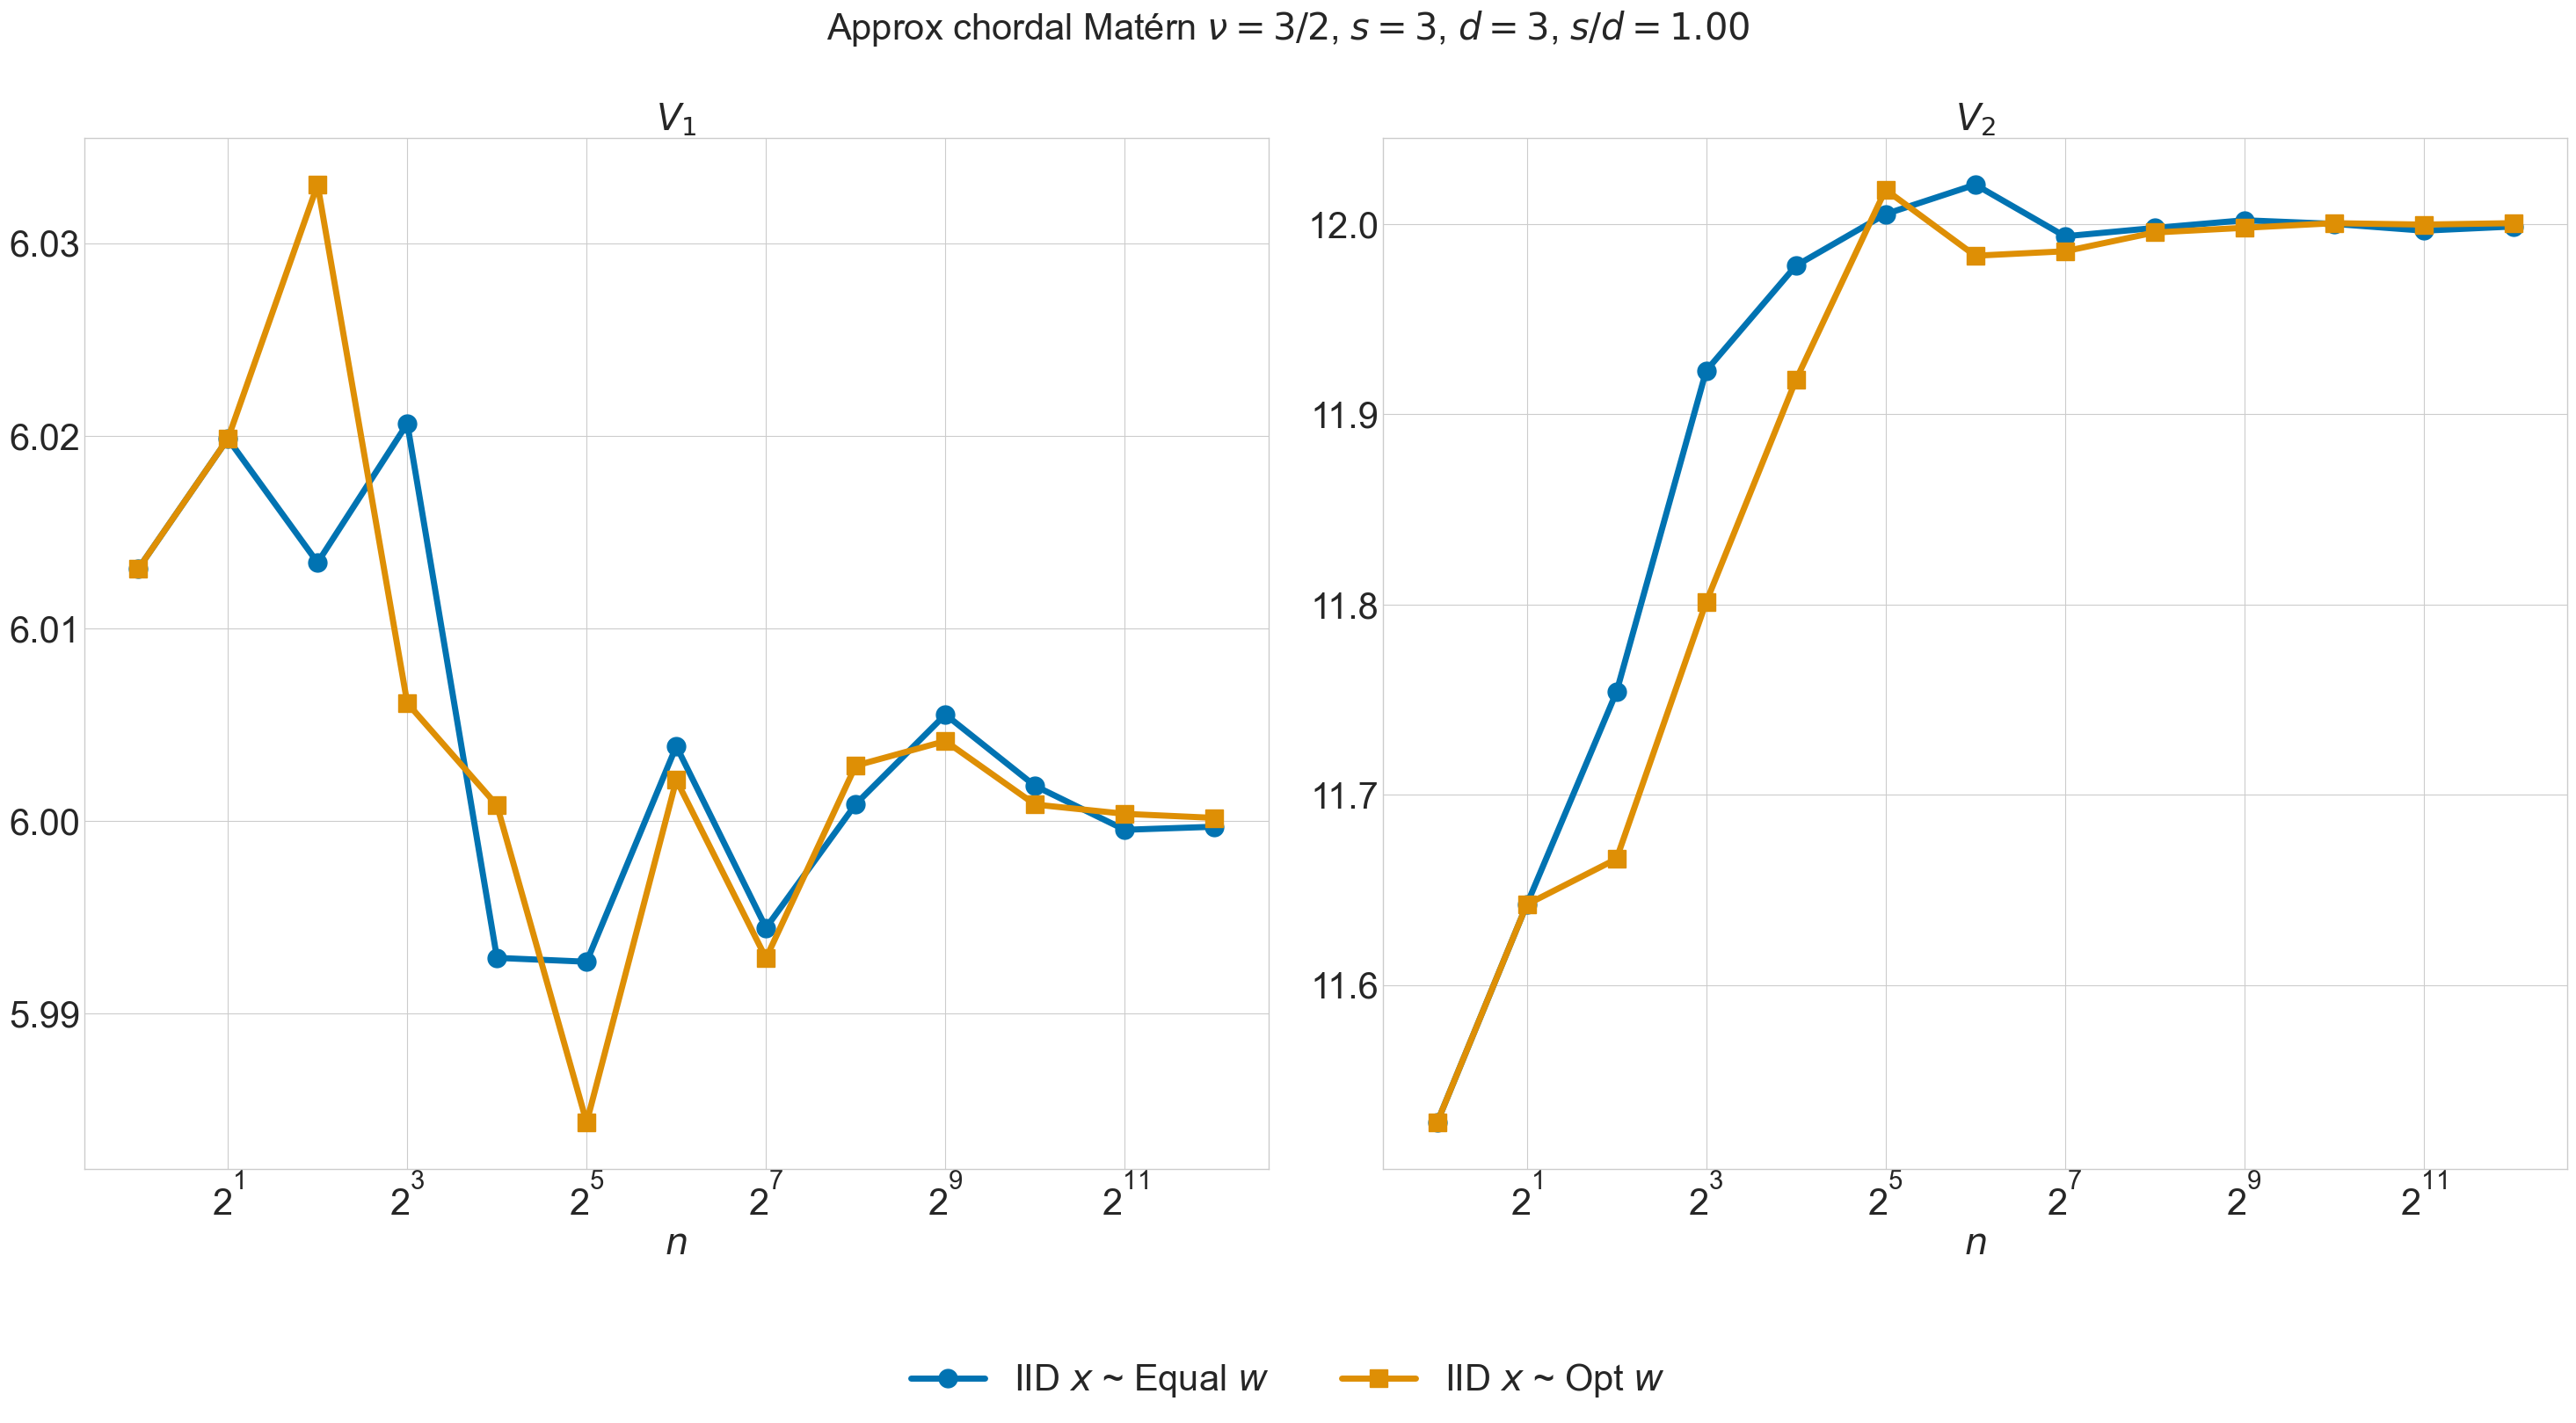

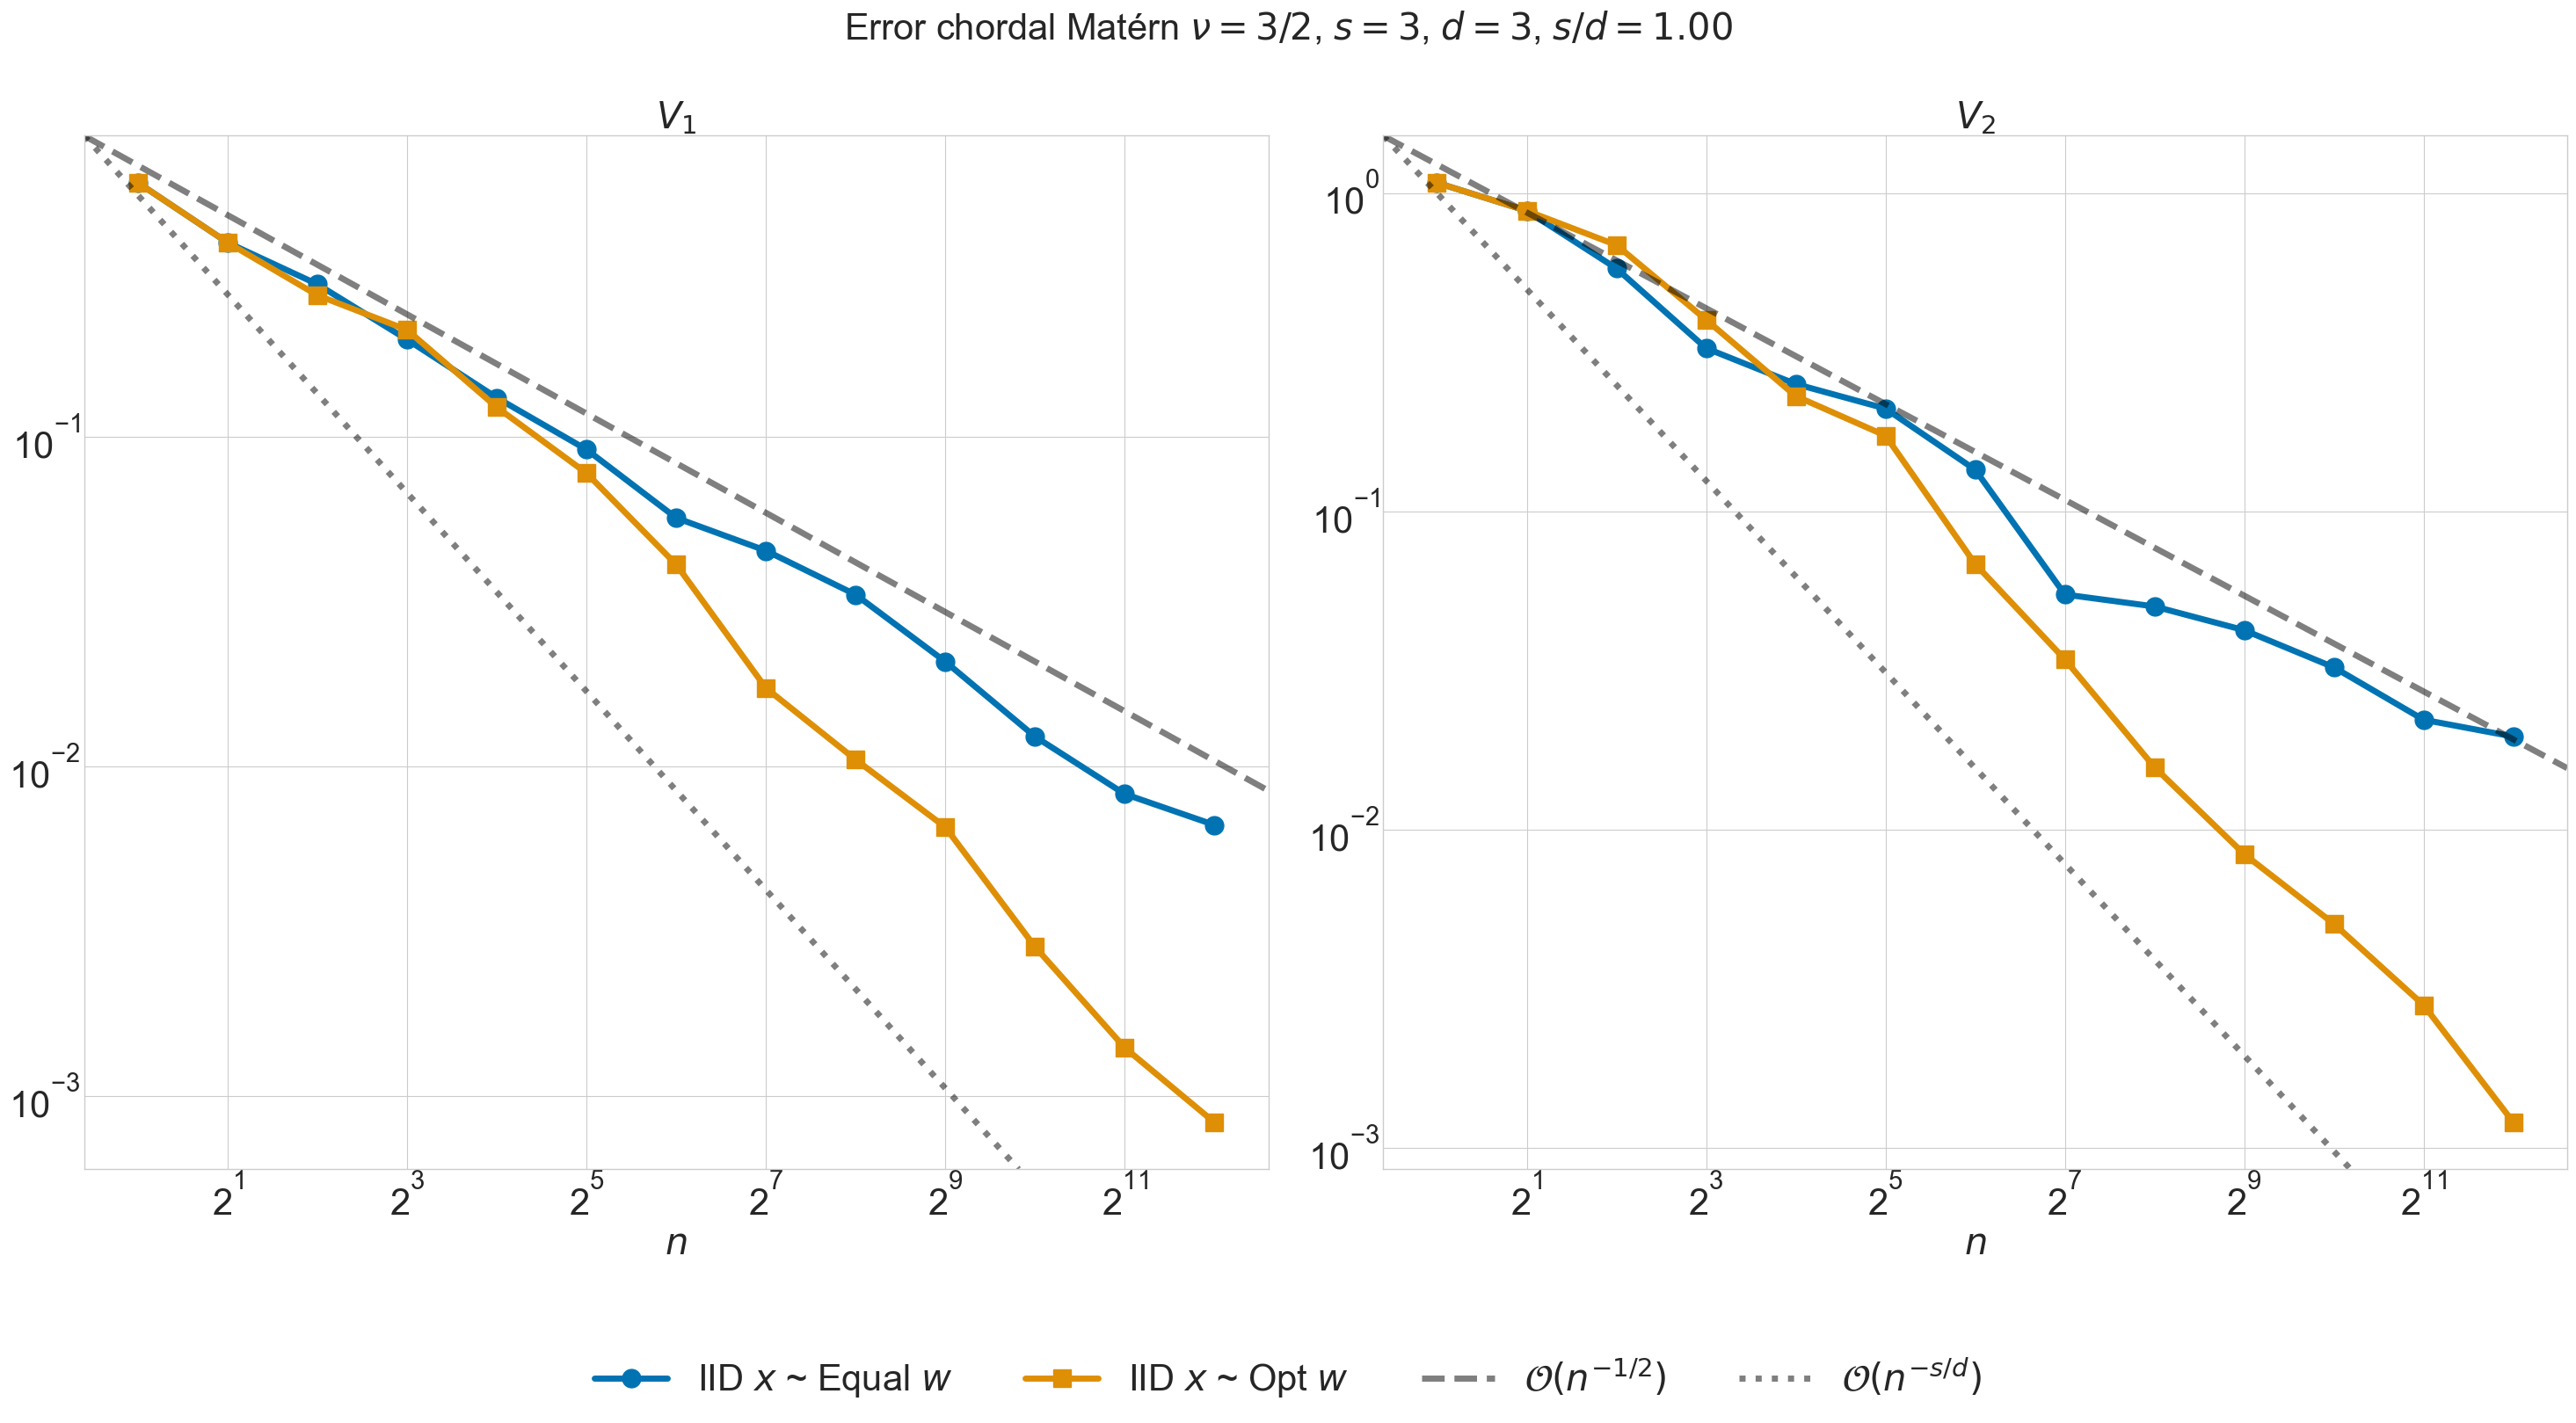

In [16]:
for l,(metric,metric_name) in enumerate(zip(
    [Vk_hats.mean(-2),errors.mean(-2)],
    ["Approx","Error"])):
    fig,ax = pyplot.subplots(nrows=1,ncols=p,figsize=(MPLP["PW"],MPLP["PW"]/p),sharex=True,sharey=False)
    for k in range(1,p+1):
        for i,(key,_) in enumerate(genf_funcs):
            ax[k-1].plot(n,metric[i,:,k],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key if k==1 else None)
        ax[k-1].set_xscale("log",base=2)
        if l==1: ax[k-1].set_yscale("log",base=10)
    for k in range(1,p+1):
        ax[k-1].set_xlabel(r"$n$")
        ax[k-1].set_title(r"$V_{%d}$"%k)
        if l==1:
            xmin,xmax = ax[k-1].get_xlim()
            ymin,ymax = ax[k-1].get_ylim()
            ax[k-1].set_xlim([xmin,xmax])
            ax[k-1].set_ylim([ymin,ymax])
            ax[k-1].axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,linestyle="dashed",label=r"$\mathcal{O}(n^{-1/2})$" if k==1 else None)
            ax[k-1].axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,linestyle="dotted",label=r"$\mathcal{O}(n^{-s/d})$" if k==1 else None)
    fig.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.1))
    assert s==np.inf or s%1 in [0,1/2]
    if s==np.inf:
        s_str = r"\infty"
    elif s%1==0:
        s_str = r"%d"%s 
    elif s%1==1/2:
        s_str = r"$%d/2$"%(2*s)
    fig.suptitle(r"%s chordal Matérn "%metric_name+kernel.nu_str+r", $s = %s$"%s_str+r", $d=%d$"%d+r", $s/d = %.2f$"%(s/d))
    fig.tight_layout()
    fig.savefig("./out/Vk.%s.%s.N%d.d%d.nu%s.png"%(case,metric_name.lower(),N,d,nu))

In [7]:
for k in range(1,p+1):
    Vk_hats_df_k = pd.DataFrame(Vk_hats[...,k].mean(-1).T,columns=[name for (name,_) in genf_funcs])
    Vk_hats_df_k['n'] = n
    Vk_hats_df_k = Vk_hats_df_k.set_index('n')
    print(r"Vk_hats for k=%d with true value %.5e"%(k,Vk_true[k]))
    display(Vk_hats_df_k);

Vk_hats for k=1 with true value 6.00000e+00


,IID $x$ ~ Equal $w$,IID $x$ ~ Opt $w$
n,,
1,6.013090,6.013090
2,6.019849,6.019849
4,6.013417,6.033046
8,6.020636,6.006121
16,5.992889,6.000813
32,5.992689,5.984343
64,6.003883,6.002129
128,5.994450,5.992870
256,6.000873,6.002873


Vk_hats for k=2 with true value 1.20000e+01


,IID $x$ ~ Equal $w$,IID $x$ ~ Opt $w$
n,,
1,11.527803,11.527803
2,11.642369,11.642369
4,11.754115,11.666347
8,11.922995,11.801356
16,11.978173,11.918048
32,12.005315,12.018138
64,12.020786,11.983418
128,11.993644,11.985761
256,11.998017,11.995648


In [8]:
for k in range(1,p+1):
    errors_df_k = pd.DataFrame(errors[...,k].median(-1).values.T,columns=[name for (name,_) in genf_funcs])
    errors_df_k['n'] = n
    errors_df_k = errors_df_k.set_index('n')
    print(r"errors for k=%d"%k)
    display(errors_df_k);

errors for k=1


,IID $x$ ~ Equal $w$,IID $x$ ~ Opt $w$
n,,
1,0.503383,0.503383
2,0.449018,0.449018
4,0.276505,0.186415
8,0.213136,0.179443
16,0.143995,0.097279
32,0.082327,0.075723
64,0.043028,0.035062
128,0.047549,0.015219
256,0.023945,0.009450


errors for k=2


,IID $x$ ~ Equal $w$,IID $x$ ~ Opt $w$
n,,
1,0.881497,0.881497
2,0.746239,0.746239
4,0.352702,0.407667
8,0.240212,0.193548
16,0.228033,0.254746
32,0.180106,0.150073
64,0.113825,0.064635
128,0.042372,0.022113
256,0.054016,0.012206
